In [ ]:
import pandas as pd
import torch
import re
import nltk
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from transformers import BertTokenizer, BertForSequenceClassification
from torch.utils.data import DataLoader, TensorDataset
from torch.optim import AdamW
from sklearn.model_selection import StratifiedKFold

nltk.download('punkt')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [ ]:
import kagglehub

path = kagglehub.dataset_download("thedrcat/daigt-v4-train-dataset")
df = pd.read_csv(f"{path}/train_v4_drcat_01.csv")
df = df[['text', 'label']]
df = df.dropna()
print("Number of rows:", len(df))
print(df.head())
print(df['label'].value_counts())

100%|██████████| 48.9M/48.9M [00:04<00:00, 10.6MB/s]

Extracting files...


Number of rows: 73573
                                                text  label
0  Phones\n\nModern humans today are always on th...      0
1  This essay will explain if drivers should or s...      0
2  Driving while the use of cellular devices\n\nT...      0
3  Phones & Driving\n\nDrivers should not be able...      0
4  Cell Phone Operation While Driving\n\nThe abil...      0
label
1    46203
0    27370
Name: count, dtype: int64


In [ ]:
df_human = df[df['label'] == 0]
df_ai = df[df['label'] == 1]
df_ai_reduced = df_ai.sample(n=22630, random_state=42)
df_balanced = pd.concat([df_human, df_ai_reduced]).sample(frac=1, random_state=42)


print("New Dataset Stats:")
print(df_balanced['label'].value_counts())
print(f"Total Rows: {len(df_balanced)}")

df=df_balanced;

print(df['label'].value_counts())

New Dataset Stats:
label
0    27370
1    22630
Name: count, dtype: int64
Total Rows: 50000
label
0    27370
1    22630
Name: count, dtype: int64


In [ ]:
def clean_text(text):
    text = str(text)
    text = re.sub(r'\s+', ' ', text)  # remove extra spaces
    return text.strip()
df['clean_text'] = df['text'].apply(lambda x: x[:200])
# df['clean_text'] = df['text'].apply(clean_text)

In [ ]:
import nltk
from nltk import pos_tag, word_tokenize

# Add these three downloads to ensure all dependencies are met
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')

def get_pos_features(text):
    tokens = word_tokenize(text)
    tags = pos_tag(tokens)

    total = len(tags) if len(tags) > 0 else 1

    noun = sum(1 for _, t in tags if t.startswith('NN')) / total
    verb = sum(1 for _, t in tags if t.startswith('VB')) / total
    adj  = sum(1 for _, t in tags if t.startswith('JJ')) / total

    return [noun, verb, adj]

# Apply
df['pos_features'] = df['clean_text'].apply(get_pos_features)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


In [ ]:
X_train, X_val, y_train, y_val, pos_train, pos_val = train_test_split(
    df['clean_text'],
    df['label'],
    df['pos_features'],
    test_size=0.2,
    random_state=42,
    stratify=df['label']
)

In [ ]:
from transformers import RobertaTokenizer

tokenizer = RobertaTokenizer.from_pretrained('roberta-base')

encoded_train = tokenizer(
    X_train.tolist(),
    padding=True,
    truncation=True,
    max_length=128,
    return_tensors='pt'
)

encoded_val = tokenizer(
    X_val.tolist(),
    padding=True,
    truncation=True,
    max_length=128,
    return_tensors='pt'
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [ ]:
train_pos = torch.tensor(pos_train.tolist(), dtype=torch.float)
val_pos = torch.tensor(pos_val.tolist(), dtype=torch.float)
train_labels = torch.tensor(y_train.values)
val_labels = torch.tensor(y_val.values)

train_dataset = TensorDataset(
    encoded_train['input_ids'],
    encoded_train['attention_mask'],
    train_pos,
    train_labels
)

val_dataset = TensorDataset(
    encoded_val['input_ids'],
    encoded_val['attention_mask'],
    val_pos,
    val_labels
)
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8)

In [ ]:
import torch.nn as nn
from transformers import RobertaModel

class RobertaBiLSTMAttention(nn.Module):
    def __init__(self):
        super().__init__()

        self.roberta = RobertaModel.from_pretrained("roberta-base")

        self.lstm = nn.LSTM(
            input_size=768,
            hidden_size=256,
            num_layers=1,
            batch_first=True,
            bidirectional=True
        )

        self.attention = nn.Linear(512, 1)

        self.dropout = nn.Dropout(0.3)

        # +3 for POS features
        self.fc = nn.Linear(512 + 3, 2)

    def forward(self, input_ids, attention_mask, pos_features):
        outputs = self.roberta(input_ids=input_ids, attention_mask=attention_mask)
        x = outputs.last_hidden_state   # (batch, seq_len, 768)

        lstm_out, _ = self.lstm(x)      # (batch, seq_len, 512)

        # Attention
        attn_weights = torch.softmax(self.attention(lstm_out), dim=1)
        context = torch.sum(attn_weights * lstm_out, dim=1)  # (batch, 512)

        # Concatenate POS features
        combined = torch.cat((context, pos_features), dim=1)

        x = self.dropout(combined)

        logits = self.fc(x)

        return logits

In [ ]:
from transformers import RobertaForSequenceClassification

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = RobertaBiLSTMAttention().to(device)
model.to(device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("Still on CPU ❌")
optimizer = AdamW(model.parameters(), lr=2e-5,weight_decay=0.01)

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


GPU: Tesla T4


In [ ]:
import torch
from transformers import get_linear_schedule_with_warmup

# Use the PyTorch native AdamW
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-5,weight_decay=0.01)

total_steps = len(train_loader) * 3

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps
)

In [ ]:
loss_fn = nn.CrossEntropyLoss()
epochs = 3

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for batch in train_loader:
        input_ids, attention_mask, pos_feats,labels = [b.to(device) for b in batch]

        logits = model(input_ids, attention_mask, pos_feats)

        loss = loss_fn(logits, labels)
        total_loss += loss.item()

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        optimizer.step()
        scheduler.step()

    print(f"Epoch {epoch+1} Loss: {total_loss/len(train_loader):.4f}")

Epoch 1 Loss: 0.4753
Epoch 2 Loss: 0.5023
Epoch 3 Loss: 0.3319


In [ ]:
model.eval()

val_preds = []
val_true = []

with torch.no_grad():
    for batch in val_loader:
        input_ids, attention_mask, pos_feats, labels = [b.to(device) for b in batch]

        logits = model(input_ids, attention_mask, pos_feats)

        probs = torch.softmax(logits, dim=1)[:, 1]
        preds = (probs > 0.7).long()   # tuned threshold

        val_preds.extend(preds.cpu().numpy())
        val_true.extend(labels.cpu().numpy())
        val_probs.extend(probs.cpu().numpy())

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

accuracy = accuracy_score(val_true, val_preds)
precision = precision_score(val_true, val_preds)
recall = recall_score(val_true, val_preds)
f1 = f1_score(val_true, val_preds)

print("\nEvaluation Metrics")
print("------------------")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

print("\nClassification Report:\n")
print(classification_report(val_true, val_preds))


Evaluation Metrics
------------------
Accuracy  : 0.9101
Precision : 0.9183
Recall    : 0.8796
F1 Score  : 0.8985

Classification Report:

              precision    recall  f1-score   support

           0       0.90      0.94      0.92      5474
           1       0.92      0.88      0.90      4526

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000



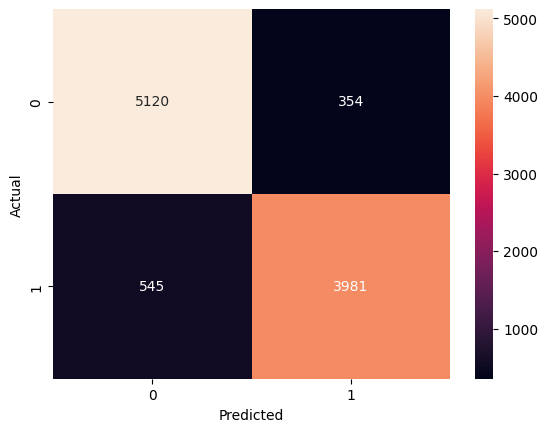

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(val_true, val_preds)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
import pandas as pd

roc_df = pd.DataFrame({
    'true': val_true,
    'prob': val_probs
})

roc_df.to_csv("roc_data.csv", index=False)

In [ ]:
def predict_text(text):
    model.eval()

    text = clean_text(text)
    # Tokenize
    encoding = tokenizer(
        text,
        padding=True,
        truncation=True,
        max_length=128,
        return_tensors='pt'
    )

    input_ids = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)

     # 🔥 ADD THIS (POS features)
    pos_feat = torch.tensor([get_pos_features(text)], dtype=torch.float).to(device)

    with torch.no_grad():
        logits = model(input_ids, attention_mask, pos_feat)
        probs = torch.softmax(logits, dim=1)

    return probs[:, 1].item()  # probability of AI class



# Example
sample = "This essay was written entirely by artificial intelligence."
print("AI Pfrom sklearn.metrics import confusion_matrix")

AI Pfrom sklearn.metrics import confusion_matrix


In [ ]:
import pandas as pd

# 1. Ensure your test sentences are in a list or array
# Replace 'test_sentences' with whatever your variable name is (e.g., X_test)
val_texts = X_val.tolist()
print(len(val_texts), len(val_true), len(val_preds))

# 2. Create the Error DataFrame
error_df = pd.DataFrame({
    'Original_Text': val_texts,
    'True_Label': val_true,
    'Predicted_Label': val_preds
})

# 3. Filter for mistakes only
# This reduces your 50k samples down to the ~2,000 mistakes (4% of 50k)
misclassified = error_df[error_df['True_Label'] != error_df['Predicted_Label']]

# 4. Show the first 20 mistakes to check
print(f"Total mistakes: {len(misclassified)}")
print(f"Total samples: {len(error_df)}")
display(misclassified.head(20))

# 5. Export to Excel/CSV so you can send it to your professor
misclassified.to_csv('model_errors.csv', index=False)

10000 10000 10000
Total mistakes: 899
Total samples: 10000


,Original_Text,True_Label,Predicted_Label
4,It is hypothesized that despite an effective w...,0,1
5,"In today's world, attending school can be a fr...",0,1
6,Technology runs rampant in this modern age. So...,0,1
16,When the government considers restrictions on ...,1,0
32,It is one of my biggest dreams to bring you on...,1,0
69,Do you think this is a good idea or not? I rea...,1,0
81,"Florida State Senator,\n\nThe Electoral Colleg...",0,1
87,"While some see the ""Face on Mars"" as evidence ...",1,0
101,If the majority of humans\n\nThe phrase if the...,1,0
103,"Dear Principal,\n\nI cannot think but about th...",1,0


In [ ]:
new_path = kagglehub.dataset_download("sunilthite/llm-detect-ai-generated-text-dataset")
new_df = pd.read_csv(f"{new_path}/Training_Essay_Data.csv")

# 2. Clean it using your existing function
new_df['clean_text'] = new_df['text'].apply(clean_text)

# 3. Create a quick loop to check the first 10 rows
for i in range(10):
    text = new_df['clean_text'].iloc[i]
    score = predict_text(text)
    actual = "AI" if new_df['generated'].iloc[i] == 1 else "Human"
    pred = "AI" if score > 0.5 else "Human"
    print(f"Actual: {actual} | Predicted: {pred} | Score: {score:.4f}")

100%|██████████| 18.6M/18.6M [00:02<00:00, 6.51MB/s]

Extracting files...


Actual: AI | Predicted: AI | Score: 0.9757
Actual: AI | Predicted: AI | Score: 0.9756
Actual: AI | Predicted: AI | Score: 0.9756
Actual: AI | Predicted: AI | Score: 0.9756
Actual: AI | Predicted: AI | Score: 0.9756
Actual: AI | Predicted: AI | Score: 0.9756
Actual: AI | Predicted: AI | Score: 0.9756
Actual: AI | Predicted: AI | Score: 0.9756
Actual: AI | Predicted: AI | Score: 0.9756
Actual: AI | Predicted: AI | Score: 0.9756


In [ ]:
print(f"Total Rows: {len(new_df)}")
print(new_df['generated'].value_counts())

Total Rows: 29145
generated
0    17508
1    11637
Name: count, dtype: int64


Testing on full dataset...

--- Testing different thresholds ---
Threshold 0.3: Accuracy = 0.9309
Threshold 0.4: Accuracy = 0.9332
Threshold 0.5: Accuracy = 0.9360
Threshold 0.6: Accuracy = 0.9437
Threshold 0.7: Accuracy = 0.9441

Detailed Classification Report:
              precision    recall  f1-score   support

       Human       0.97      0.92      0.95     17508
          AI       0.89      0.96      0.92     11637

    accuracy                           0.94     29145
   macro avg       0.93      0.94      0.93     29145
weighted avg       0.94      0.94      0.94     29145



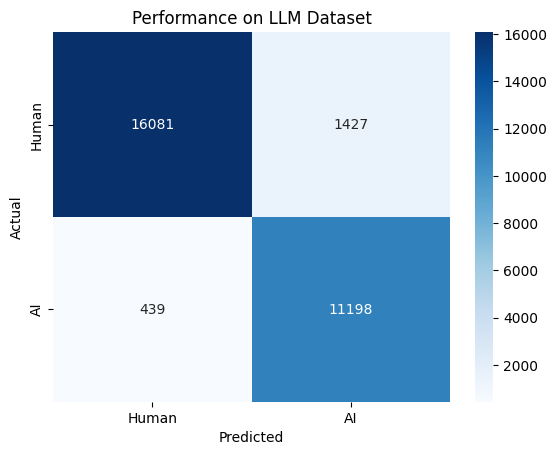

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Get predictions for the entire new dataset (this might take a minute)
print("Testing on full dataset...")
new_df['ai_score'] = new_df['clean_text'].apply(predict_text)

print("\n--- Testing different thresholds ---")
for t in [0.3, 0.4, 0.5, 0.6, 0.7]:
    temp_preds = (new_df['ai_score'] > t).astype(int)
    print(f"Threshold {t}: Accuracy = {accuracy_score(new_df['generated'], temp_preds):.4f}")

# 2. Calculate Accuracy
# acc = accuracy_score(new_df['label'], new_df['final_pred'])
# print(f"\n✅ Accuracy on New Dataset: {acc:.4f}")

best_t = 0.5
new_df['final_pred'] = (new_df['ai_score'] > best_t).astype(int)

# 3. Show Detailed Report
print("\nDetailed Classification Report:")
print(classification_report(new_df['generated'], new_df['final_pred'], target_names=['Human', 'AI']))

# 4. Plot Confusion Matrix
cm = confusion_matrix(new_df['generated'], new_df['final_pred'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Human', 'AI'], yticklabels=['Human', 'AI'])
plt.title('Performance on LLM Dataset')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

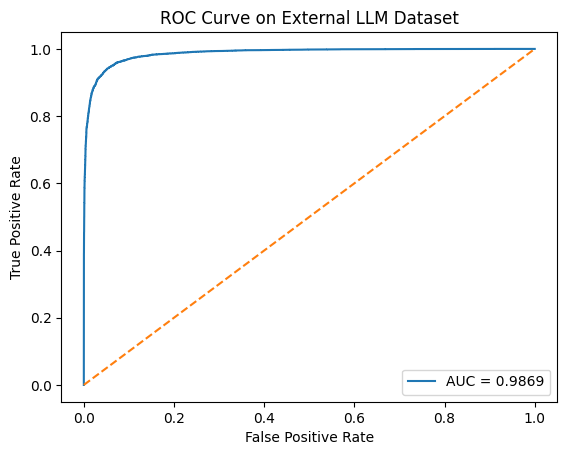

AUC Score: 0.9869


In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# True labels and predicted probabilities
y_true = new_df['generated']
y_probs = new_df['ai_score']

# Compute ROC
fpr, tpr, thresholds = roc_curve(y_true, y_probs)
roc_auc = auc(fpr, tpr)

# Plot
plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve on External LLM Dataset")
plt.legend()

plt.show()

# Print AUC
print(f"AUC Score: {roc_auc:.4f}")

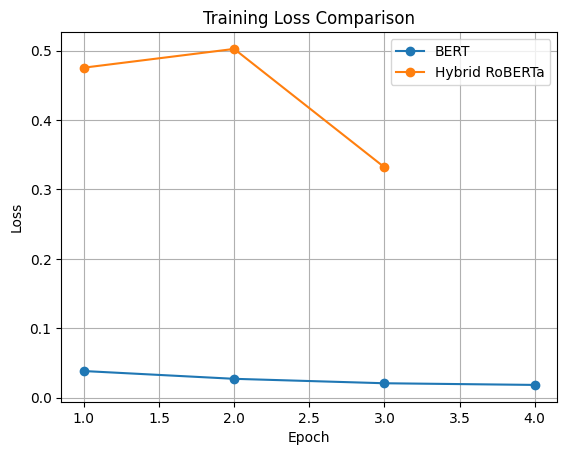

In [ ]:
import matplotlib.pyplot as plt

epochs_bert = [1,2,3,4]
loss_bert = [0.0385, 0.0273, 0.0209, 0.0185]

epochs_hybrid = [1,2,3]
loss_hybrid = [0.4753, 0.5023, 0.3319]

plt.plot(epochs_bert, loss_bert, marker='o', label='BERT')
plt.plot(epochs_hybrid, loss_hybrid, marker='o', label='Hybrid RoBERTa')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Comparison')
plt.legend()
plt.grid()

plt.savefig("loss_curve.png")
plt.show()